In [1]:
from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader

C:\Users\Madhumitha R\AppData\Local\Temp\ipykernel_28240\133196705.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, WebBaseLoader
d:\PROJECTS\GEN AI Projects\PyAssistant\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


loading documents:

In [41]:
doc1=PyPDFLoader("pdf_srcs/Python Cheatsheet.pdf")
doc2=PyPDFLoader("pdf_srcs/Python Interview Codes Cheatsheet.pdf")
doc3=PyPDFLoader("pdf_srcs/PYTHON SHORTHANDS.pdf")
doc4=PyPDFLoader("pdf_srcs/python-to-mysql.pdf")
doc5=PyPDFLoader("pdf_srcs/Tutorial_EDIT.pdf")

In [42]:
python_docs=doc1.load()+doc2.load()+doc3.load()+doc4.load()+doc5.load()
python_docs[0]

Document(metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'pdf_srcs/Python Cheatsheet.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Python Cheastsheet\nImporting packages\nPython packages are a collection of useful tools developed by the open-source \ncommunity. They extend the capabilities of the python language. To install a new \npackage (for example, pandas), you can go to your command prompt and type in pip \ninstall pandas. Once a package is installed, you can import it as follows.\nimport pandas  # Import a package without an alias\nimport pandas as pd   # Import a package with an alias\nfrom pandas import dataframe  # Import an object from a package\nBasics\nArithmetic operators\nAssignment operators\nNumeric comparison operators\nLogical operators\n102 + 37 # Add two numbers with +\n102 - 37 # Subtract a number with-\n4 * 6 # Multiply two numbers with *\n22 / 7 # Divide a number by another with/\n22 / / 7 # Integer divide 

In [43]:
len(python_docs)

248

loading websites:

In [44]:
web=[
    "https://docs.python.org/3/tutorial/",
    "https://pynative.com/python/",
    "https://www.w3schools.com/python/python_intro.asp",
    "https://www.programiz.com/python-programming/examples",
    "https://www.geeksforgeeks.org/python/python-programming-examples/"
]

web_loader=WebBaseLoader(web)
python_web_docs=web_loader.load()

In [45]:
python_web_docs

[Document(metadata={'source': 'https://docs.python.org/3/tutorial/', 'title': 'The Python Tutorial — Python 3.14.8 documentation', 'description': 'Python is an easy to learn, powerful programming language. It has efficient high-level data structures and a simple but effective approach to object-oriented programming. Python’s elegant syntax an...', 'language': 'en'}, page_content='\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nThe Python Tutorial — Python 3.14.8 documentation\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n    Theme\n    \nAuto\nLight\nDark\n\n\n\nPrevious topic\nChangelog\n\n\nNext topic\n1. Whetting Your Appetite\n\n\n\nThis page\n\nReport a bug\nImprove this page\n\nShow source\n        \n\n\n\n\n\n\n\nNavigation\n\n\nindex\n\nmodules |\n\nnext |\n\nprevious |\n\nPython »\n\n\n\n\n\n\n\n3.14.8 Documentation »\n    \nThe Python Tutorial\n\n\n\n\n\n\n\n                     |\n                \n\n\n    Theme\n    \nAuto\nLight

In [46]:
len(python_web_docs)

5

combining both sources

In [47]:
combined_src=python_docs+python_web_docs
combined_src[0]

Document(metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '', 'source': 'pdf_srcs/Python Cheatsheet.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Python Cheastsheet\nImporting packages\nPython packages are a collection of useful tools developed by the open-source \ncommunity. They extend the capabilities of the python language. To install a new \npackage (for example, pandas), you can go to your command prompt and type in pip \ninstall pandas. Once a package is installed, you can import it as follows.\nimport pandas  # Import a package without an alias\nimport pandas as pd   # Import a package with an alias\nfrom pandas import dataframe  # Import an object from a package\nBasics\nArithmetic operators\nAssignment operators\nNumeric comparison operators\nLogical operators\n102 + 37 # Add two numbers with +\n102 - 37 # Subtract a number with-\n4 * 6 # Multiply two numbers with *\n22 / 7 # Divide a number by another with/\n22 / / 7 # Integer divide 

In [48]:
len(combined_src)

253

document chunking:

In [49]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

In [50]:
chunked_docs = splitter.split_documents(combined_src)
len(chunked_docs)

563

embeddings:

In [51]:
from langchain_community.embeddings import HuggingFaceEmbeddings
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1550.80it/s]


vector db:

In [52]:
from langchain_community.vectorstores import Chroma

persist_directory = '/db/chroma'

document injection:

In [53]:
vectordb=Chroma.from_documents(
    documents=chunked_docs,
    embedding=embeddings,
    persist_directory=persist_directory
)

In [54]:
sample_question = "What is the difference between list and tuple in Python?"

In [55]:
vectordb.similarity_search(sample_question, k=3)

[Document(metadata={'creationdate': '2018-09-02T00:46:10+00:00', 'title': 'Python Tutorial', 'page': 41, 'source': 'data/Tutorial_EDIT.pdf', 'producer': 'xdvipdfmx (0.7.9)', 'moddate': '2018-09-02T11:19:20-07:00', 'total_pages': 155, 'page_label': '36', 'creator': 'LaTeX with hyperref package', 'author': 'Guido van Rossum, and the Python development team'}, page_content="Tuples are immutable, and usually contain a heterogeneous sequence of elements that are accessed via\nunpacking (see later in this section) or indexing (or even by attribute in the case ofnamedtuples). Lists are\nmutable, and their elements are usually homogeneous and are accessed by iterating over the list.\nA special problem is the construction of tuples containing 0 or 1 items: the syntax has some extra quirks to\naccommodate these. Empty tuples are constructed by an empty pair of parentheses; a tuple with one item is\nconstructed by following a value with a comma (it is not suﬃcient to enclose a single value in par

retrieval:

In [56]:
vectordb.max_marginal_relevance_search(sample_question, k=3)

[Document(metadata={'author': 'Guido van Rossum, and the Python development team', 'page': 41, 'creator': 'LaTeX with hyperref package', 'producer': 'xdvipdfmx (0.7.9)', 'moddate': '2018-09-02T11:19:20-07:00', 'total_pages': 155, 'title': 'Python Tutorial', 'source': 'data/Tutorial_EDIT.pdf', 'page_label': '36', 'creationdate': '2018-09-02T00:46:10+00:00'}, page_content="Tuples are immutable, and usually contain a heterogeneous sequence of elements that are accessed via\nunpacking (see later in this section) or indexing (or even by attribute in the case ofnamedtuples). Lists are\nmutable, and their elements are usually homogeneous and are accessed by iterating over the list.\nA special problem is the construction of tuples containing 0 or 1 items: the syntax has some extra quirks to\naccommodate these. Empty tuples are constructed by an empty pair of parentheses; a tuple with one item is\nconstructed by following a value with a comma (it is not suﬃcient to enclose a single value in par

prompt engineering:

In [57]:
from langchain_ollama import ChatOllama
llm = ChatOllama(
    model="gemma4:31b-cloud",
    temperature=0
)

In [58]:
response=llm.invoke(sample_question)

In [59]:
response.content

'The simplest way to remember the difference is: **Lists are mutable (changeable), and tuples are immutable (unchangeable).**\n\nHere is a detailed breakdown of the differences across several categories:\n\n### 1. Mutability (The Main Difference)\n*   **List:** You can add, remove, or change elements after the list has been created.\n*   **Tuple:** Once a tuple is created, you cannot change its contents. You cannot add, delete, or replace elements.\n\n```python\n# List example\nmy_list = [1, 2, 3]\nmy_list[0] = 99  # Works! [99, 2, 3]\n\n# Tuple example\nmy_tuple = (1, 2, 3)\nmy_tuple[0] = 99 # Raises a TypeError\n```\n\n### 2. Syntax\n*   **List:** Defined using square brackets `[]`.\n*   **Tuple:** Defined using parentheses `()`.\n\n### 3. Performance\n*   **List:** Slightly slower. Because lists can grow and shrink, Python must allocate extra memory to accommodate future changes.\n*   **Tuple:** Faster. Because they are fixed in size, Python stores them more efficiently in memory. I

In [60]:
from langchain_core.messages import HumanMessage,SystemMessage
human_msg=[HumanMessage(content=sample_question)]
result=llm.invoke(human_msg)
result.content

'The primary difference between a list and a tuple in Python is **mutability**. In short: **lists are mutable** (can be changed), and **tuples are immutable** (cannot be changed).\n\nHere is a detailed breakdown of the differences:\n\n### 1. Mutability (The Main Difference)\n*   **List:** You can add, remove, or modify elements after the list has been created.\n*   **Tuple:** Once a tuple is created, you cannot change its contents. You cannot add, delete, or replace items.\n\n```python\n# List example\nmy_list = [1, 2, 3]\nmy_list[0] = 99  # Works! [99, 2, 3]\n\n# Tuple example\nmy_tuple = (1, 2, 3)\nmy_tuple[0] = 99 # Raises a TypeError\n```\n\n### 2. Syntax\n*   **List:** Defined using square brackets `[]`.\n*   **Tuple:** Defined using parentheses `()`.\n\n### 3. Performance\n*   **List:** Slightly slower. Because they are mutable, Python must allocate extra memory to allow for potential growth.\n*   **Tuple:** Slightly faster. Because they are fixed in size, Python stores them more

memory

In [61]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

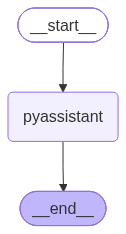

In [62]:
workflow=StateGraph(state_schema=MessagesState)

def call_model(state:MessagesState):
    system_prompt= f"""
            You are a helpful assistant.
            Answer the questions to the best of your ability.
            If the answer cannot be found in the documents,
            say that you don't have enough information.
        """
    
    messages=[SystemMessage(content=system_prompt)]+state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

workflow.add_node("pyassistant", call_model)
workflow.add_edge(START, "pyassistant")

memory=MemorySaver()
app=workflow.compile(checkpointer=memory)
app

testing:

In [63]:
user_input=input("Ask a question about Python: ")
print(user_input)

explain string formating


In [64]:
messages=[HumanMessage(content=user_input)]

In [65]:
llm_ans = app.invoke(
    {"messages": messages},
    config={"configurable": {"thread_id": "thread_1"}}
)

rendering the output in readable format:

In [66]:
from IPython.display import Markdown
Markdown(llm_ans["messages"][-1].content)

**String formatting** is the process of inserting variables or expressions into a string to create a dynamic message. Instead of manually adding strings together (concatenation), formatting allows you to create a "template" with placeholders that get filled in later.

Here is an explanation of the most common ways to do this, using Python as the primary example since it has the most diverse formatting options.

---

### 1. The "Old Way": `%` Formatting (C-Style)
This is the oldest method. It uses the `%` operator as a placeholder for specific data types.

*   `%s` $\rightarrow$ String
*   `%d` $\rightarrow$ Integer
*   `%f` $\rightarrow$ Floating-point number

**Example:**
```python
name = "Alice"
age = 30
print("Hello, %s. You are %d years old." % (name, age))
# Output: Hello, Alice. You are 30 years old.
```

---

### 2. The "Intermediate Way": `.format()`
Introduced to be more flexible than the `%` operator. It uses curly braces `{}` as placeholders.

**Example:**
```python
name = "Bob"
city = "New York"
print("Hello, {}. Welcome to {}!".format(name, city))
# Output: Hello, Bob. Welcome to New York!
```
**Why it's better:** You can reorder arguments or reuse them:
`print("{0} loves {1}, and {0} really loves {1}!".format("Alice", "Coding"))`

---

### 3. The "Modern Way": f-Strings (Formatted String Literals)
Introduced in Python 3.6, **f-strings** are the current industry standard because they are faster to run and much easier to read. You simply put an `f` before the quotation marks and put the variables directly inside the braces.

**Example:**
```python
name = "Charlie"
score = 95.5
print(f"Student: {name} | Score: {score}")
# Output: Student: Charlie | Score: 95.5
```
**Advanced Power:** You can even perform math or call functions inside the braces:
`print(f"Next year you will be {age + 1} years old.")`

---

### Common Formatting Tricks (Precision & Padding)
Regardless of the method, string formatting is often used to make data look "clean."

#### A. Controlling Decimals (Precision)
If you have a number like `3.14159265` but only want two decimal places:
*   **f-string:** `f"{pi:.2f}"` $\rightarrow$ `3.14`

#### B. Adding Padding/Alignment
Useful for creating tables in a console:
*   `f"{name:>10}"` $\rightarrow$ Right-aligns the text within 10 spaces.
*   `f"{name:<10}"` $\rightarrow$ Left-aligns the text within 10 spaces.
*   `f"{name:^10}"` $\rightarrow$ Centers the text within 10 spaces.

---

### Summary Table

| Method | Syntax | Readability | Performance | Recommendation |
| :--- | :--- | :--- | :--- | :--- |
| **% Operator** | `"Hello %s" % var` | Low | Slow | Avoid (Legacy) |
| **.format()** | `"Hello {}".format(var)` | Medium | Medium | Use for complex templates |
| **f-Strings** | `f"Hello {var}"` | High | Fast | **Best for most cases** |